In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [28]:
df = pd.read_parquet("data/features.parquet")

In [29]:
df.head()

,age,monthly_price,avg_watch_hours_per_week,number_of_logins_per_week,days_since_last_watch,completion_rate,tickets_last_30d,price_increase_last_6m,payment_failures,churn_type,...,country_Portugal,country_South Africa,country_South Korea,country_Spain,country_Thailand,country_UK,country_USA,plan_Basic,plan_Premium,plan_Standard
0,34,14.99,0.38,1,10,0.40,5,0,0,0,...,False,False,False,False,False,True,False,False,False,True
1,41,19.99,6.87,4,49,0.89,3,1,2,2,...,False,True,False,False,False,False,False,False,True,False
2,60,9.99,19.15,13,4,0.30,4,0,2,0,...,False,False,False,False,False,True,False,True,False,False
3,38,9.99,19.54,20,4,0.21,2,0,1,0,...,False,False,False,False,True,False,False,True,False,False
4,39,14.99,1.50,20,9,0.28,0,0,1,0,...,False,False,False,False,False,False,False,False,False,True


In [30]:
# drop leaky and redundant features
X = df.drop(columns=["churn_type", "is_cancelled", "monthly_price"])
y = df["churn_type"]

In [31]:
# check class balance
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(1))

churn_type
0    7630
2    2026
1     344
Name: count, dtype: int64
churn_type
0    76.3
2    20.3
1     3.4
Name: proportion, dtype: float64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

Train shape: (8000, 32)
Test shape: (2000, 32)

Train class distribution:
churn_type
0    76.3
2    20.3
1     3.4
Name: proportion, dtype: float64


In [33]:
# define models
# class_weight="balanced" automatically adjusts weights inversely proportional to class frequency
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced", 
            max_iter=1000, 
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            n_estimators=100,
            random_state=42
        ))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42,
            verbosity=0
        ))
    ])
}

In [34]:
from sklearn.utils.class_weight import compute_sample_weight

results = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    
    # XGBoost needs sample_weight passed at fit time
    if name == "XGBoost":
        sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    
    results[name] = {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, 
      target_names=["Renews", "Cancels Early", "Won't Renew"],
      zero_division=0))

Training Logistic Regression...

--- Logistic Regression ---
               precision    recall  f1-score   support

       Renews       0.96      0.81      0.88      1526
Cancels Early       0.09      0.36      0.15        69
  Won't Renew       0.53      0.57      0.55       405

     accuracy                           0.75      2000
    macro avg       0.53      0.58      0.52      2000
 weighted avg       0.84      0.75      0.79      2000

Training Random Forest...

--- Random Forest ---
               precision    recall  f1-score   support

       Renews       0.91      0.95      0.93      1526
Cancels Early       0.00      0.00      0.00        69
  Won't Renew       0.69      0.71      0.70       405

     accuracy                           0.87      2000
    macro avg       0.54      0.55      0.54      2000
 weighted avg       0.84      0.87      0.85      2000

Training XGBoost...

--- XGBoost ---
               precision    recall  f1-score   support

       Renews       0

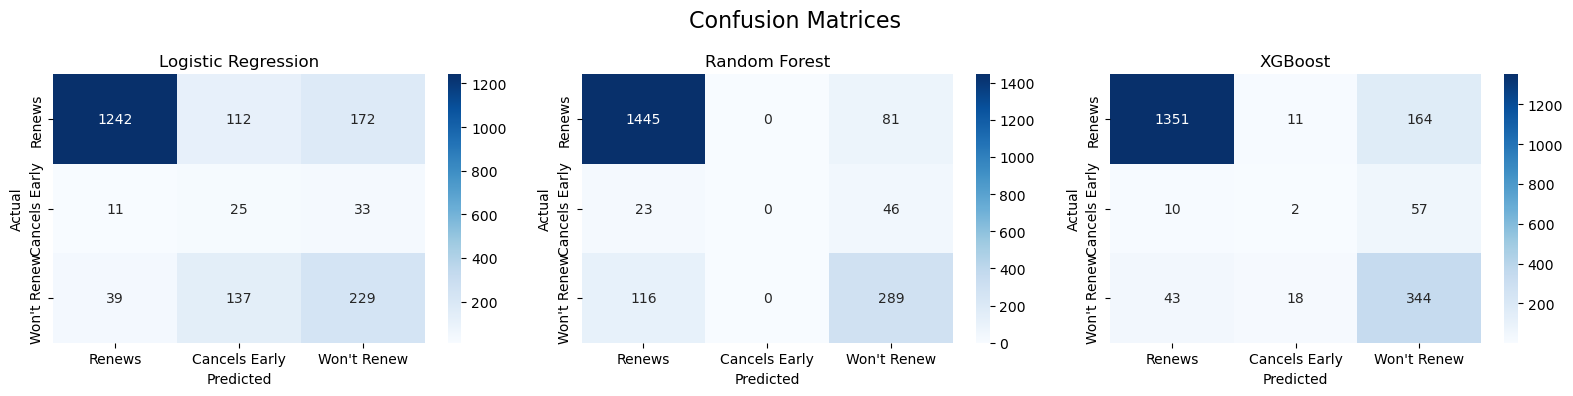

In [35]:
# confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Renews", "Cancels Early", "Won't Renew"],
                yticklabels=["Renews", "Cancels Early", "Won't Renew"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.savefig("graphs/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# ROC-AUC score for all 3 models (one-vs-rest for multiclass)
print("ROC-AUC Scores (OvR macro):")
for name, result in results.items():
    auc = roc_auc_score(y_test, result["y_prob"], multi_class="ovr", average="macro")
    print(f"  {name}: {auc:.4f}")

ROC-AUC Scores (OvR macro):
  Logistic Regression: 0.8782
  Random Forest: 0.9174
  XGBoost: 0.9147


In [37]:
# model comparison summary table
summary = []
for name, result in results.items():
    report = classification_report(y_test, result["y_pred"], 
                                   output_dict=True, zero_division=0,
                                   target_names=["Renews", "Cancels Early", "Won't Renew"])
    auc = roc_auc_score(y_test, result["y_prob"], multi_class="ovr", average="macro")
    summary.append({
        "Model": name,
        "Accuracy": round(report["accuracy"], 3),
        "Macro F1": round(report["macro avg"]["f1-score"], 3),
        "Cancels Early F1": round(report["Cancels Early"]["f1-score"], 3),
        "ROC-AUC": round(auc, 4)
    })

summary_df = pd.DataFrame(summary).set_index("Model")
print(summary_df)

                     Accuracy  Macro F1  Cancels Early F1  ROC-AUC
Model                                                             
Logistic Regression     0.748     0.524             0.146   0.8782
Random Forest           0.867     0.544             0.000   0.9174
XGBoost                 0.849     0.557             0.040   0.9147


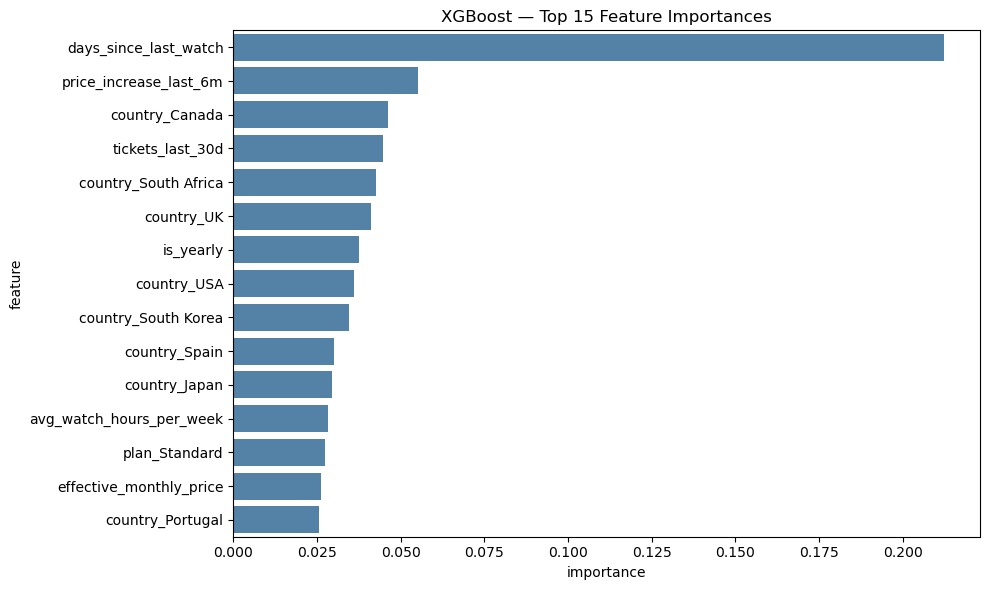

In [38]:
# XGBoost feature importance
xgb_model = results["XGBoost"]["pipeline"].named_steps["model"]
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("graphs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# save the best model
joblib.dump(results["XGBoost"]["pipeline"], "models/xgboost_churn.pkl")
print("Model saved.")

Model saved.


In [40]:
import json
feature_cols = X_train.columns.tolist()
with open("models/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)
print("Feature columns saved.")

Feature columns saved.
